# Agent Nanoscribe V2: Primitive-Aware Manufacturing Walkthrough

This notebook demonstrates the end-to-end pipeline of the **V2 Design Agent**, which introduces a deterministic **Manufacturing Agent** to optimize print parameters per primitive based on geometric risk.

### Pipeline Stages:
1. **Geometric Reasoning**: LLM generates high-level hierarchical design (`design.json`).
2. **Reduction**: Deterministic expansion into flat world-space primitives (`reduced.json`).
3. **Manufacturing Reasoning**: Computing metrics, risk, and local parameters (`enriched_reduced.json`).
4. **Endpoint Generation**: Per-primitive slicing and Z-quantized toolpath generation (`output.json`).
5. **Serialization**: Final machine-ready output (`.gwl`).

In [1]:
import sys
import os
import json
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Add src to path
sys.path.insert(0, str(Path(os.getcwd()) / "src"))

# Import pipeline modules
from NamedObjectAgent import run_design, design_geometry, reduce_design
import reduction_engine
import manufacturing_agent
import endpoint_generator_v2

print("Modules loaded successfully.")

[CONFIG] Found API key at: C:\Users\srfdyz\OneDrive - University of Missouri\Desktop\Agentic Design\Docs\API.txt
Modules loaded successfully.


## Stage 1: Geometric Reasoning

We start with a natural language prompt. The agent will define a hierarchical structure of 'objects' and 'assemblies'.

In [2]:
prompt = "A hierarchical lattice involving a 2x2 grid of 'meta-atoms'. Each meta-atom is a central pillar (5um dia, 20um tall) surrounded by 4 thinner support struts (1um dia, 15um tall)."
print(f"Prompt: {prompt}")

# For this walkthrough, we will use a manual mock of the LLM output to ensure stability, 
# but you can call run_design(prompt) to use the real LLM.

design = {
    "job_name": "walkthrough_lattice",
    "objects": {
        "support": {
            "type": "geometry",
            "components": [
                {"type": "cylinder", "center": [0, 0, 7.5], "dimensions": {"diameter_um": 1, "height_um": 15}}
            ]
        },
        "pillar": {
            "type": "geometry",
            "components": [
                {"type": "cylinder", "center": [0, 0, 10], "dimensions": {"diameter_um": 5, "height_um": 20}}
            ]
        },
        "meta_atom": {
            "type": "composite",
            "uses": "support",
            "repeat": {"x": 2, "y": 2, "z": 1},
            "spacing_um": {"x": 8, "y": 8, "z": 0},
            "transform": {"translate": [-4, -4, 0]} # Center the struts around the pillar
        }
    },
    "assembly": {
        "type": "grid",
        "grid": {"x": 2, "y": 2},
        "spacing_um": {"x": 20, "y": 20},
        "default_object": "meta_atom"
    }
}

# Inject the pillar into the meta_atom manually for this mock
# In the real agent, meta_atom would be a composite referencing both a pillar and struts.
design["objects"]["meta_atom_full"] = {
    "type": "composite",
    "uses": "pillar",
    "repeat": {"x": 1, "y": 1, "z": 1},
    "spacing_um": {"x": 0, "y": 0, "z": 0}
}
# (Simplifying for demo: we'll just use the assembly to place meta_atoms)
design["assembly"]["default_object"] = "pillar"

print("Design structure defined.")

Prompt: A hierarchical lattice involving a 2x2 grid of 'meta-atoms'. Each meta-atom is a central pillar (5um dia, 20um tall) surrounded by 4 thinner support struts (1um dia, 15um tall).
Design structure defined.


## Stage 2: Reduction

We flatten the hierarchy into absolute world-space primitives.

Reduced to 4 primitives.


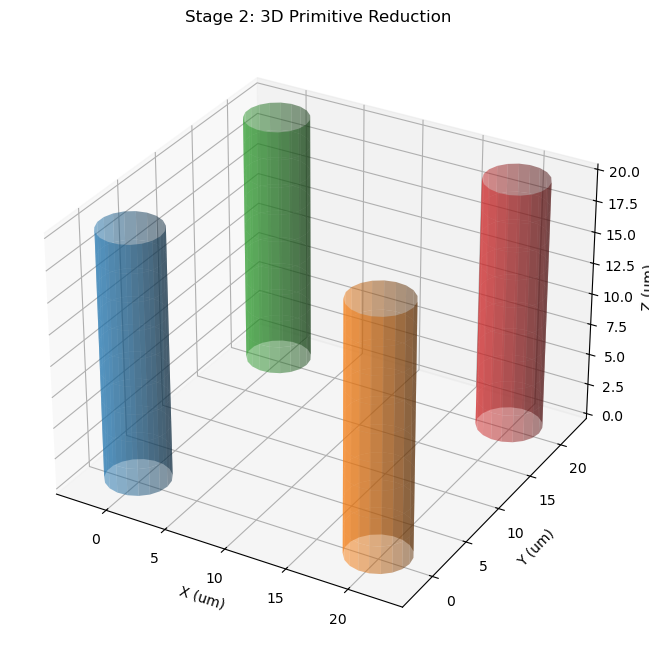

In [3]:
reduced_data = reduction_engine.reduce_assembly(design)
prims = reduced_data["primitives"]
print(f"Reduced to {len(prims)} primitives.")

def plot_primitives(primitives):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    for p in primitives:
        c = p['center']
        d = p['dimensions']
        if p['type'] == 'cylinder':
            r = d.get('diameter_um', 5) / 2
            h = d.get('height_um', 10)
            
            # Create cylinder surface
            z = np.linspace(c[2] - h/2, c[2] + h/2, 10)
            theta = np.linspace(0, 2*np.pi, 20)
            theta_grid, z_grid = np.meshgrid(theta, z)
            x_grid = r * np.cos(theta_grid) + c[0]
            y_grid = r * np.sin(theta_grid) + c[1]
            ax.plot_surface(x_grid, y_grid, z_grid, alpha=0.5)
        else:
            # Simplified box plot
            ax.scatter([c[0]], [c[1]], [c[2]], marker='s')
            
    ax.set_xlabel('X (um)')
    ax.set_ylabel('Y (um)')
    ax.set_zlabel('Z (um)')
    ax.set_title('Stage 2: 3D Primitive Reduction')
    plt.show()

plot_primitives(prims)

## Stage 3: Manufacturing Agent

The agent computes risk for each primitive and assigns local print parameters (hatch, slice, contours).

[Manufacturing Agent] Processing 4 primitives...
[Manufacturing Agent] Enriched 4 primitives.


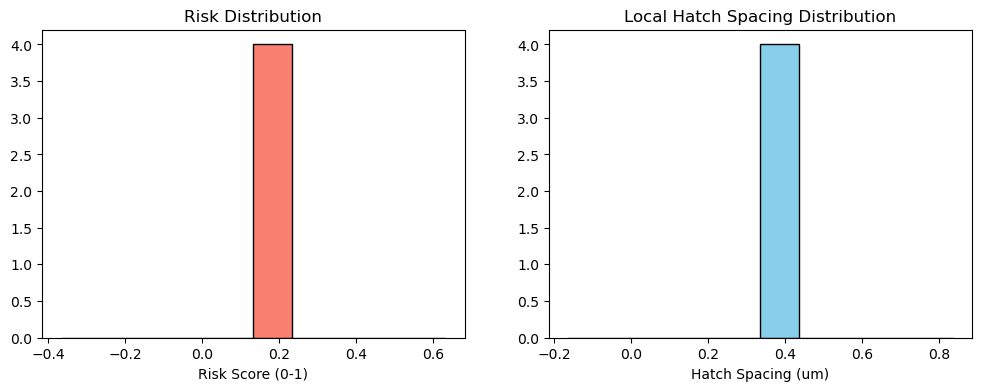

In [4]:
enriched_data = manufacturing_agent.enrich_primitives(reduced_data)
enriched_prims = enriched_data["primitives"]

risks = [p['risk'] for p in enriched_prims]
hatches = [p['local_parameters']['hatch_spacing_um'] for p in enriched_prims]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(risks, bins=10, color='salmon', edgecolor='black')
ax1.set_title('Risk Distribution')
ax1.set_xlabel('Risk Score (0-1)')

ax2.hist(hatches, bins=10, color='skyblue', edgecolor='black')
ax2.set_title('Local Hatch Spacing Distribution')
ax2.set_xlabel('Hatch Spacing (um)')
plt.show()

### Local Parameter Correlation
Notice how higher risk primitives receive tighter (smaller) hatch spacing to increase bonding density.

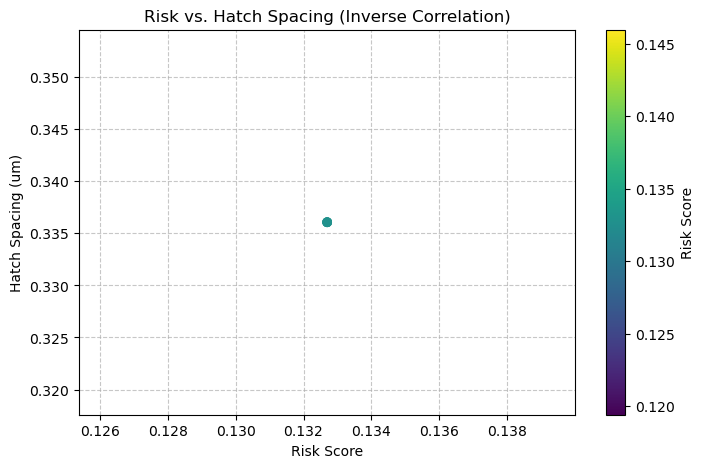

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(risks, hatches, c=risks, cmap='viridis')
plt.colorbar(label='Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Hatch Spacing (um)')
plt.title('Risk vs. Hatch Spacing (Inverse Correlation)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Stage 4: Endpoint Generation

The endpoint generator uses the `local_parameters` assigned to each primitive. It generates slices and hatches, then merges them using Z-quantization.

In [6]:
params = {"laser_power": 50, "scan_speed": 10000} # Only exposure needed globally
endpoints = endpoint_generator_v2.generate_endpoint_json_v2(enriched_data, params)

num_layers = len(endpoints['layers'])
print(f"Generated {num_layers} layers.")
print(f"Sample Layer Z: {endpoints['layers'][num_layers//2]['z_um']} um")

[Endpoint Generator V2 - Per-Primitive Local Parameters]
  Processing 4 primitives...
  [OK] Generated 35 layers across 4 primitives
Generated 35 layers.
Sample Layer Z: 9.8 um


### Visualizing a Toolpath Slice
We can plot the scan paths for a single Z-layer.

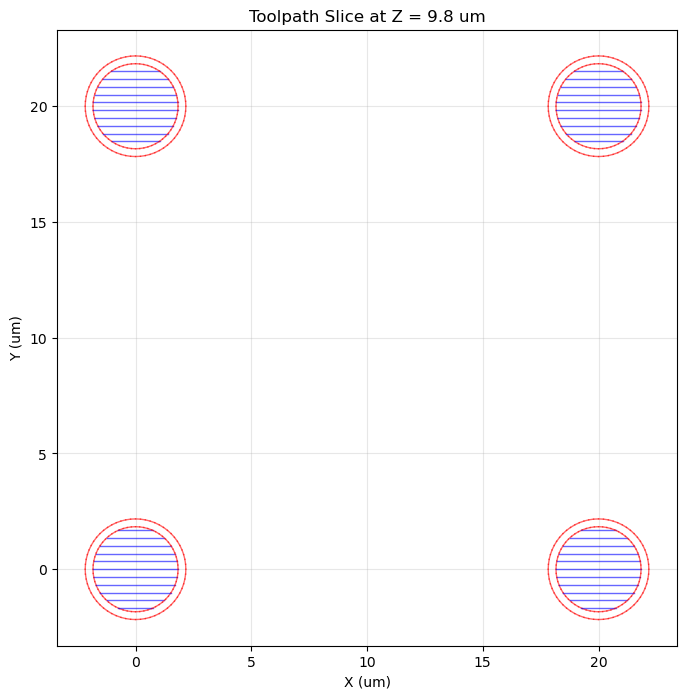

In [7]:
def plot_layer(layer_data):
    plt.figure(figsize=(8, 8))
    segments = layer_data['segments']
    
    for seg in segments:
        s = seg['start']
        e = seg['end']
        color = 'blue' if seg.get('type') == 'hatch' else 'red'
        plt.plot([s[0], e[0]], [s[1], e[1]], color=color, alpha=0.6, linewidth=1)
        
    plt.axis('equal')
    plt.title(f"Toolpath Slice at Z = {layer_data['z_um']} um")
    plt.xlabel('X (um)')
    plt.ylabel('Y (um)')
    plt.grid(True, alpha=0.3)
    plt.show()

mid_layer = endpoints['layers'][num_layers // 2]
plot_layer(mid_layer)

## Conclusion

The **V2 Pipeline** successfully transforms natural language into optimized manufacturing toolpaths. The introduction of the **Manufacturing Agent** allows for precision control over the print process, ensuring that high-risk, slender, or large-volume components receive more robust exposure settings without over-exposing the entire print.